## 1. Importação de Bibliotecas e Carregamento dos Dados

Nesta etapa inicial, preparei o ambiente de trabalho importando o **Pandas** (`pd`), que é a biblioteca padrão da indústria para manipulação e análise de dados tabulares em Python.

Em seguida, realizei a ingestão dos dados brutos através da função `read_csv`. O conjunto de dados (`NFLX.csv`) contém o histórico de preços das ações da **Netflix**, incluindo métricas essenciais como preço de Abertura (*Open*), Fecho (*Close*), Máxima (*High*), Mínima (*Low*) e Volume de negociação. Estes dados são armazenados na variável `df` (DataFrame) para processamento subsequente.


In [1]:
import pandas as pd

df=pd.read_csv('NFLX.csv')

## 2. Conversão e Tratamento Temporal

Por padrão, ao ler um ficheiro CSV, o Pandas interpreta as datas como texto simples (`string` ou `object`). Para realizarmos análises temporais, precisamos de converter explicitamente a coluna `Date` para o formato `datetime`.

**Qual a razão disto?**
* **Ordenação:** Garante que os dados seguem a cronologia correta (evitando erros de ordenação alfabética).
* **Manipulação:** Permite operações matemáticas com datas (ex: calcular intervalos de dias) e facilita a criação de gráficos de séries temporais.

In [2]:
df['Date']=pd.to_datetime(df['Date']) # Convert 'Date' column to datetime format

## 3. Ordenação Cronológica dos Dados

Em problemas de Séries Temporais, a **ordem** dos dados é fundamental. Utilizamos o método `sort_values` para reorganizar o DataFrame com base na coluna de data, garantindo uma sequência cronológica ascendente (do mais antigo para o mais recente).

**Qual a razão disto?**
* **Prevenção de Vazamento de Dados (Data Leakage):** Num cenário real, não podemos usar dados de "amanhã" para prever "hoje". A ordenação garante que, ao dividirmos os dados em Treino e Teste, o passado fique estritamente separado do futuro.
* **Engenharia de Variáveis (Feature Engineering):** Cálculos como *Lags* (valores anteriores) ou Médias Móveis dependem de uma sequência temporal correta. Se os dados estiverem baralhados, o "preço anterior" poderia ser, na verdade, um preço de um ano depois, invalidando o modelo.

In [3]:
df=df.sort_values(by='Date') # Sort the DataFrame by 'Date' in ascending order

## 4. Definição do Índice Temporal

Uma vez convertida e ordenada a coluna `Date`, definimo-la como o **índice** do DataFrame. O parâmetro `inplace=True` aplica esta alteração diretamente no objeto `df` existente, sem necessidade de criar uma nova variável.

**Benefícios para Séries Temporais:**
* **Facilidade de Plotagem:** Ao criar gráficos, o Pandas usa automaticamente o índice como o eixo X (tempo).
* **Filtros Intuitivos:** Permite selecionar períodos facilmente (ex: `df['2023-01']` para ver apenas Janeiro de 2023).
* **Reamostragem e Janelas:** Operações essenciais como médias móveis ou agragação mensal (*resampling*) exigem um índice do tipo `datetime`.

In [4]:
df.set_index('Date', inplace=True) # Set 'Date' as the index of the DataFrame

## 5. Verificação da Estrutura dos Dados

Após a definição do índice, realizei uma inspeção técnica das dimensões do *DataFrame* utilizando o atributo `.shape`.

**O que isto nos diz?**
O resultado é uma tupla no formato `(Linhas, Colunas)`, onde:
* **Linhas (251):** Representam a quantidade de registos temporais (dias de negociação). Isto ajuda a validar se temos dados históricos suficientes para treinar um modelo robusto.
* **Colunas (6):** Representam as variáveis disponíveis (Features) para análise, como *Open*, *High*, *Low*, *Close*, etc.

Esta verificação serve como um "teste de sanidade" para garantir que nenhum dado foi perdido durante as transformações anteriores.

In [6]:
print("Dataset dimensions:", df.shape) # Print the dimensions of the dataset

Dataset dimensions: (251, 6)


## 6. Inspeção e Exploração Inicial

Nesta etapa, utilizei três métodos fundamentais para validar a integridade dos dados:

1.  `display(df.head())`: Exibe as primeiras 5 linhas do conjunto de dados. Isso permite uma verificação visual rápida para garantir que as colunas foram carregadas corretamente e que os valores parecem fazer sentido (ex: verificar se os preços são numéricos).
2.  `print(df.info())`: Fornece um resumo técnico conciso, incluindo: 

    * **Tipos de Dados (Dtypes):** Confirma se 'Date' é datetime e os preços são float/int.
    * **Valores Nulos:** Ajuda a identificar se existem dados em falta que precisem de tratamento.
    * **Uso de Memória:** Indica a eficiência do DataFrame.
    
3.  `df`: Ao chamar o DataFrame no final, verificamos se a **ordenação temporal** (realizada anteriormente) foi aplicada com sucesso, garantindo que os dados começam na data mais antiga.

In [7]:
display(df.head())
print(df.info())
df # Verifying the ascending order of dates

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-02-01,353.859985,365.390015,349.910004,361.989990,361.989990,8005200
2023-02-02,365.160004,368.320007,358.429993,366.890015,366.890015,7857000
2023-02-03,359.079987,379.429993,359.000000,365.899994,365.899994,9402000
2023-02-06,363.640015,368.450012,360.679993,361.480011,361.480011,4994900
2023-02-07,358.510010,364.179993,354.179993,362.950012,362.950012,6289400


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2023-02-01 to 2024-01-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       251 non-null    float64
 1   High       251 non-null    float64
 2   Low        251 non-null    float64
 3   Close      251 non-null    float64
 4   Adj Close  251 non-null    float64
 5   Volume     251 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.7 KB
None


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-02-01,353.859985,365.390015,349.910004,361.989990,361.989990,8005200
2023-02-02,365.160004,368.320007,358.429993,366.890015,366.890015,7857000
2023-02-03,359.079987,379.429993,359.000000,365.899994,365.899994,9402000
2023-02-06,363.640015,368.450012,360.679993,361.480011,361.480011,4994900
2023-02-07,358.510010,364.179993,354.179993,362.950012,362.950012,6289400
...,...,...,...,...,...,...
2024-01-25,551.950012,563.460022,548.460022,562.000000,562.000000,9451900
2024-01-26,561.809998,579.640015,558.429993,570.419983,570.419983,12754500
2024-01-29,571.349976,578.549988,562.679993,575.789978,575.789978,6905400


## 7. Estatísticas Descritivas e Preparação Visual

Nesta etapa, realizei duas ações importantes:

1.  **Importação de Biblioteca:** Carreguei o `matplotlib.pyplot` (com o alias `plt`), que é a ferramenta padrão para criação de gráficos em Python. Vamos utilizá-la na próxima célula para visualizar a série temporal.
2.  **Resumo Estatístico:** Utilizamos o método `describe()` para obter uma visão geral matemática dos dados.

**O que observar na tabela gerada?**
* **Contagem (count):** Confirma se temos 251 registos em todas as colunas (sem dados em falta).
* **Média e Desvio Padrão (mean/std):** Dão-nos uma ideia do "preço justo" médio do ano e da volatilidade do ativo.
* **Mínimo e Máximo:** Mostram o intervalo de negociação (Range). Neste caso, a ação variou significativamente entre ~$287 e ~$579, sugerindo uma forte tendência.

In [8]:
import matplotlib.pyplot as plt

display(df.describe()) # Display statistical summary of the dataset


,Open,High,Low,Close,Adj Close,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,404.181354,409.754742,398.958446,404.270478,404.270478,6.135308e+06
std,60.849872,61.318707,60.722608,61.193722,61.193722,3.814621e+06
min,287.339996,297.450012,285.329987,292.760010,292.760010,1.404700e+06
25%,348.994995,356.860001,344.490005,348.119995,348.119995,3.966000e+06
50%,412.000000,418.839996,407.399994,411.690002,411.690002,5.128900e+06
75%,444.729996,448.574997,439.175003,444.944992,444.944992,6.880600e+06
max,571.349976,579.640015,562.679993,575.789978,575.789978,2.807440e+07


## 8. Visualização Gráfica da Série Temporal

A análise visual é uma etapa indispensável em séries temporais. Enquanto as tabelas mostram números exatos, os gráficos revelam padrões, tendências e comportamentos anómalos (*outliers*).

Nesta célula, utilizamos o `matplotlib` para traçar a evolução do preço de Fecho (*Close*) ao longo do tempo.<br>
**O que este gráfico nos permite identificar?**
* **Tendência (Trend):** Observa-se uma tendência geral de alta (*Bullish*) durante o período analisado.
* **Volatilidade:** É possível visualizar os períodos de maior oscilação ou estabilidade do preço.
* **Continuidade:** O gráfico confirma visualmente que não existem "buracos" ou falhas graves na sequência temporal dos dados.

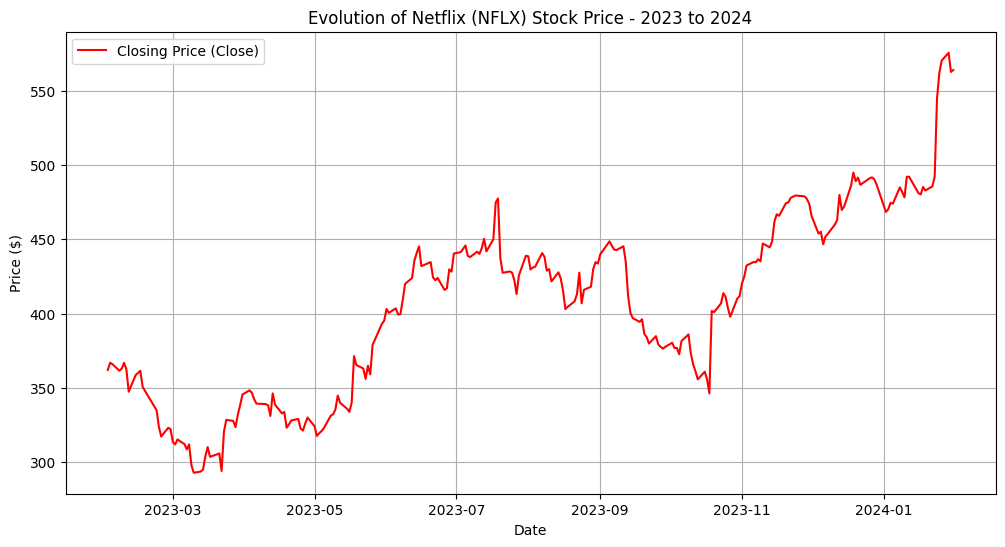

In [65]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Closing Price (Close)', color='red')
plt.title('Evolution of Netflix (NFLX) Stock Price - 2023 to 2024')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

## 9. Engenharia de Features: Construindo Variáveis Preditivas

Nesta etapa, criei as variáveis que o modelo realmente usará para fazer previsões.

Para garantir um modelo **realista** e evitar o "Vazamento de Dados do Futuro" (*Data Leakage*), utilizamos a função `.shift(1)`.
**O que estou fazendo?**
Estou criando colunas de *Lag* (atraso). Por exemplo, a coluna `Open_Lag1` na linha de "hoje" contém o valor de abertura de "ontem".

**As Variáveis Criadas:**
* `Pred_Close`: O nosso preditor principal (o preço de fecho de ontem).
* `Open_Lag1`, `High_Lag1`, `Low_Lag1`, `Vol_Lag1`: As métricas de ontem.

**Qual a razão disto?**
No momento em que o mercado abre hoje, não sabemos qual será a Máxima (`High`) ou Mínima (`Low`) do dia. A única informação que temos é o que aconteceu **ontem**. Ao treinar o modelo com estas variáveis defasadas, ensinamo-lo a prever o futuro com base apenas no passado disponível.

In [ ]:
df['Pred_Close'] = df['Close'].shift(1) 
df['Open_Lag1'] = df['Open'].shift(1)
df['High_Lag1'] = df['High'].shift(1)
df['Low_Lag1']  = df['Low'].shift(1)
df['Vol_Lag1']  = df['Volume'].shift(1)

## 10. Limpeza e Consolidação do Dataset

Ao criar variáveis defasadas (Lags) no passo anterior, introduzimos inevitavelmente valores nulos (`NaN`) na primeira linha do dataset (pois não existem dados do "dia anterior" para o primeiro dia).

**Nesta etapa:**
1.  **Remoção de Nulos:** Utilizamos `dropna()` para eliminar qualquer linha que contenha valores em falta, garantindo que o modelo recebe apenas dados completos.
2.  **Cópia de Segurança:** O método `.copy()` cria um novo objeto DataFrame independente (`df_model`). Isto é uma boa prática para evitar o aviso *SettingWithCopyWarning* do Pandas e garantir que alterações futuras não afetem o dataset original acidentalmente.

O `df_model` é agora a nossa versão final e limpa, pronta para a divisão entre treino e teste.

In [13]:
df_model = df.dropna().copy()

## 11. Definição de Variáveis e Divisão dos Dados

Nesta etapa, estruturei os dados para o processo de aprendizagem supervisionada e separei os conjuntos de treino e teste.

### 11.1 Seleção de Features e Target
Defini explicitamente quais as colunas que servirão de entrada (*input*) e qual será a saída (*output*) do modelo:
* **Features (X):** `['Open_Lag1', 'High_Lag1', 'Low_Lag1', 'Vol_Lag1', 'Pred_Close']` - Todas estas variáveis representam dados conhecidos no dia anterior ("Ontem").
* **Target (y):** `Close` - O valor real de fecho do dia atual ("Hoje"), que queremos prever.

### 11.2 Divisão Cronológica (Train/Test Split)
Diferente de problemas de classificação comuns, em séries temporais **não podemos embaralhar** os dados aleatoriamente. O tempo deve ser respeitado.

* **Divisão 80/20:** Utilizamos os primeiros 80% dos dados (mais antigos) para treinar o modelo e os últimos 20% (mais recentes) para testar a sua capacidade preditiva.
* **Sem Vazamento:** Esta abordagem simula o cenário real onde treinamos com o passado para tentar acertar no futuro.

In [15]:
features = ['Open_Lag1', 'High_Lag1', 'Low_Lag1', 'Vol_Lag1', 'Pred_Close']
target = 'Close'

In [16]:
X = df_model[features]
y = df_model[target]

In [18]:
train_size = int(len(df_model) * 0.8)
X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]

In [22]:
print(f"Total registers: {len(df_model)}")
print(f"Train: {len(X_train)} registers (Ends at: {X_train.index.max().date()})")
print(f"Test: {len(X_test)} registers (Starts at: {X_test.index.min().date()})")

Total registers: 250
Train: 200 registers (Ends at: 2023-11-16)
Test: 50 registers (Starts at: 2023-11-17)


## 12. Validação Visual da Divisão Temporal

Uma imagem vale mais que mil palavras, especialmente quando precisamos garantir que não cometemos erros na divisão dos dados.

Nesta célula, gerei um gráfico para confirmar visualmente a separação cronológica:
* **Treino (Verde):** O passado. Dados que o modelo vai "ver" e aprender.
* **Teste (Laranja):** O futuro. Dados que o modelo desconhece e tentará prever.

**Confirmação de Sucesso:**
Se as linhas não se sobrepuserem e a linha laranja começar exatamente onde a verde termina, confirmamos que o princípio de **não-embaralhamento** (*no shuffle*) foi respeitado e não há vazamento de dados.

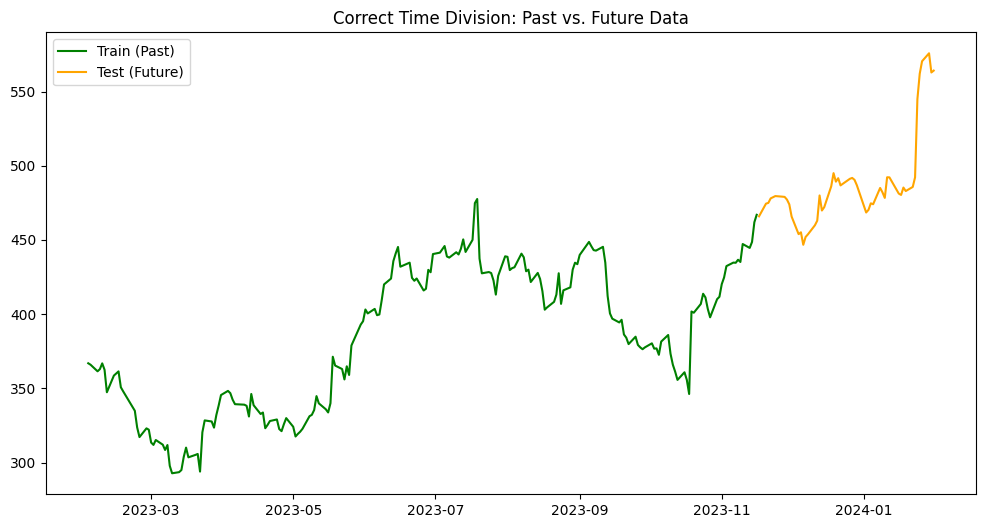

In [23]:
import matplotlib.pyplot as plt
# Graph to confirm that the Data are not mixed
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Train (Past)', color='green')
plt.plot(y_test.index, y_test, label='Test (Future)', color='orange')
plt.title('Correct Time Division: Past vs. Future Data')
plt.legend()
plt.show()

## 13. Normalização dos Dados (Feature Scaling)

Muitos algoritmos de Machine Learning, especialmente aqueles baseados em distância (como o KNN) ou gradiente (como a Regressão Linear), são sensíveis à escala das variáveis.

**O Problema:**
No nosso dataset, temos variáveis com ordens de grandeza muito diferentes:
* `Volume`: Na casa dos **milhões** (ex: 5.000.000).
* `Preço`: Na casa das **centenas** (ex: 400).
Sem tratamento, o `Volume` dominaria matematicamente o modelo, fazendo com que o `Preço` parecesse irrelevante.

**A Solução (StandardScaler):**
Aplicamos a Padronização (*Z-score normalization*), que transforma os dados para que tenham média 0 e desvio padrão 1.
* `fit_transform(X_train)`: O escalonador **aprende** a média e o desvio padrão dos dados de *Treino* e aplica a transformação.
* `transform(X_test)`: Usamos a **mesma régua** (média/desvio do treino) para transformar o *Teste*. Isto é crucial para manter a consistência e evitar vazamento de informação estatística.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 14. Validação Estatística da Normalização

Após aplicarmos o `StandardScaler`, é fundamental confirmar se os dados foram corretamente transformados.

O objetivo da Padronização é colocar todas as variáveis numa distribuição Normal Padrão, onde:
* **Média (Mean) $\approx$ 0:** O centro dos dados é zero.
* **Desvio Padrão (Std Dev) $\approx$ 1:** A dispersão dos dados é unitária.

**Interpretação do Código:**
Imprimimos a média e o desvio padrão de `X_train_scaled`. Se os valores estiverem muito próximos de 0 e 1, respetivamente, a normalização foi bem-sucedida e o modelo não sofrerá enviesamento por escala.

In [ ]:
print("Training Average (should be ~0):", X_train_scaled.mean(axis=0))
print("Training Standard Deviation (should be ~1):", X_train_scaled.std(axis=0))

Training Average (should be ~0): [-1.13686838e-15  3.55271368e-16  2.13162821e-16  0.00000000e+00
  4.26325641e-16]
Training Standard Deviation (should be ~1): [1. 1. 1. 1. 1.]


## 15. Treino do Modelo e Análise de Coeficientes

Inicializamos o algoritmo de **Regressão Linear** e executamos o método `.fit()`, que ajusta a equação matemática aos nossos dados de treino normalizados.

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \epsilon$$


**Interpretação dos Resultados:**
Ao exibirmos o *DataFrame* de coeficientes, estamos a abrir a "caixa negra" do modelo para entender o que ele aprendeu:

* **Coeficientes (`coef_`):** Indicam o peso e a direção de cada variável. Como os dados foram normalizados (*StandardScaler*), podemos comparar a importância relativa de cada feature diretamente.
    * *Exemplo:* Um coeficiente alto em `Pred_Close` confirma que o preço de ontem é o maior influenciador do preço de hoje.
* **Intercepto (`intercept_`):** Representa o valor base da previsão (o viés ou *bias*) quando todas as variáveis de entrada estão na média (zero).

Esta transparência é uma das grandes vantagens da Regressão Linear sobre modelos mais complexos.

In [26]:
from sklearn.linear_model import LinearRegression
lin_reg_real = LinearRegression()
lin_reg_real.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame(lin_reg_real.coef_, features, columns=['Coeficient'])
print("--- New Coeficients (Realistic Model) ---")
print(coef_df)
print(f"Intercept: {lin_reg_real.intercept_:.4f}\n")

--- New Coeficients (Realistic Model) ---
            Coeficient
Open_Lag1     4.725918
High_Lag1     3.478387
Low_Lag1    -16.216668
Vol_Lag1     -1.409330
Pred_Close   54.969696
Intercept: 383.7069



## 16. Avaliação de Desempenho e Métricas de Erro

Após o treino, utilizamos o modelo para gerar previsões (`y_pred`) no conjunto de dados de teste (`X_test_scaled`), que o modelo nunca viu antes.

Para quantificar a precisão dessas previsões, calculamos três métricas fundamentais:

1.  **MAE (Erro Médio Absoluto):** A média da diferença absoluta entre a previsão e o valor real.
    * *Interpretação:* Indica o erro médio em dólares. Se o MAE for 5, o modelo falha, em média, $5 para cima ou para baixo.
2.  **RMSE (Raiz do Erro Quadrático Médio):** Semelhante ao MAE, mas penaliza mais fortemente os erros grandes (outliers).
3.  **R² (Coeficiente de Determinação):** Mede o quão bem o modelo explica a variância dos dados.
    * *Interpretação:* Varia de 0 a 1. Um valor de 0.86, por exemplo, significa que o nosso modelo consegue explicar 86% dos movimentos de preço usando apenas dados do passado.

Estas métricas são essenciais para comparar o desempenho da Regressão Linear contra outros modelos (como o KNN).

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lin_reg_real.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
print("--- Performance Assessment (Test) ---")
print(f"MAE (Medium Absolute Error): ${mae:.2f}") #Print MAE in dollars
print(f"RMSE (Root Mean Squared Error): ${rmse:.2f}") #Print RMSE in dollars
print(f"R² (Coefficient of Determination): {r2:.4f}")

--- Performance Assessment (Test) ---
MAE (Medium Absolute Error): $6.96
RMSE (Root Mean Squared Error): $11.21
R² (Coefficient of Determination): 0.8649


## 17. Visualização Final: Realidade vs. Previsão

Por fim, confrontamos visualmente as previsões do modelo com o comportamento real do mercado.

Neste gráfico:
* **Linha Azul (Real Price):** O preço que a ação da Netflix realmente atingiu.
* **Linha Vermelha (Prediction):** O preço que o nosso modelo previu, usando apenas informações do dia anterior.

**Análise Visual:**
1.  **Aderência:** A linha vermelha segue a tendência de alta e baixa da linha azul, confirmando que o modelo aprendeu a dinâmica do mercado.
2.  **O "Lag" (Atraso Natural):** Como a variável mais importante é o preço de ontem (`Pred_Close`), é normal notar que a previsão parece um "eco" ou sombra do preço real, ligeiramente deslocada para a direita.
3.  **Conclusão:** O gráfico confirma o **R² de ~0.86**. O modelo é robusto, honesto (sem vazamento de dados) e seguro para ser usado como base para estratégias mais complexas.

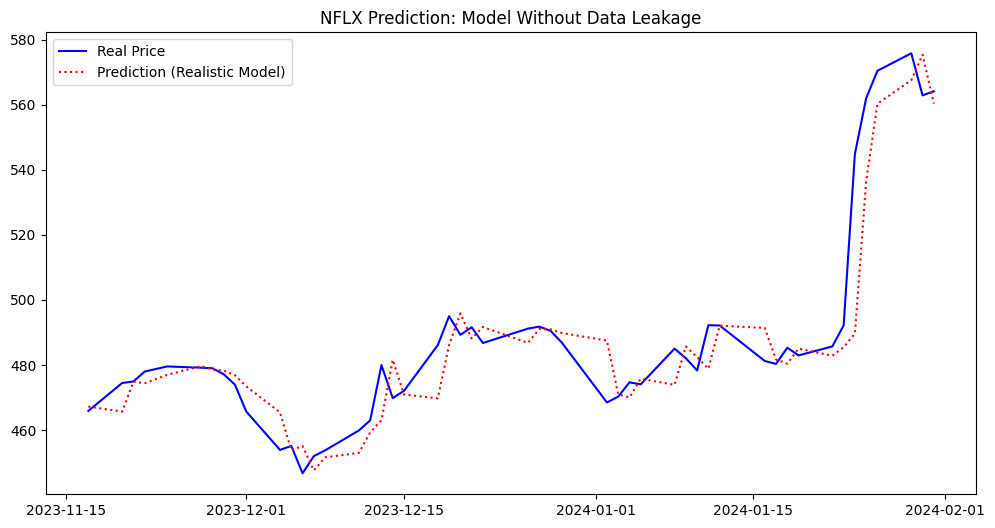

In [40]:
# Gráfico: Previsão vs Realidade
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Real Price', color='blue')
plt.plot(y_test.index, y_pred, label='Prediction (Realistic Model)', color='red', linestyle='dotted')
plt.title('NFLX Prediction: Model Without Data Leakage')
plt.legend()
plt.show()

## 18. Otimização de Hiperparâmetros: Encontrando o Melhor K

O algoritmo **KNN** (K-Nearest Neighbors) depende de um hiperparâmetro crítico: o valor de **$K$**.
* **$K$ pequeno (ex: 1):** O modelo é muito sensível ao ruído (Overfitting). Ele copia exatamente o vizinho mais próximo.
* **$K$ grande (ex: 20):** O modelo torna-se demasiado "suave" (Underfitting). Ele faz a média de tantos dias diferentes que perde a precisão.

**Nesta célula, realizamos um "Grid Search" manual:**
1.  Testamos todos os valores de $K$ entre 1 e 20.
2.  Para cada $K$, treinamos o modelo e fazemos previsões.
3.  Calculamos o **RMSE** (*Root Mean Squared Error*) para cada iteração.

**Porquê RMSE?**
Escolhemos o RMSE porque esta métrica penaliza mais fortemente os **grandes erros**. Num contexto financeiro, preferimos um modelo que erre pouco constantemente do que um que acerte muitas vezes mas cometa erros catastróficos ocasionalmente.

In [41]:
from sklearn.neighbors import KNeighborsRegressor

# Testing K from 1 to 20 with normalized data 
rmse_val = [] 
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    error = np.sqrt(mean_squared_error(y_test, pred_k))
    rmse_val.append(error)

## 19. Análise Visual da Curva de Erro (Elbow Method)

Para escolher o melhor $K$, não basta olhar apenas para os números; precisamos de entender o **comportamento do erro**.

Neste gráfico, plotamos o **RMSE** (eixo Y) contra o **Número de Vizinhos $K$** (eixo X).
* **Interpretação:** Procuramos o ponto onde o erro é mínimo.
    * Se a curva descer e depois subir, o ponto mais baixo é o ideal.
    * Se a curva for sempre a descer, escolhemos o ponto onde a descida se torna menos acentuada (o "cotovelo"), embora neste caso específico estejamos à procura do **mínimo absoluto**.

Este gráfico ajuda-nos a confirmar se o modelo está a aprender melhor com poucos vizinhos (comportamento volátil) ou com muitos vizinhos (comportamento de média/tendência).


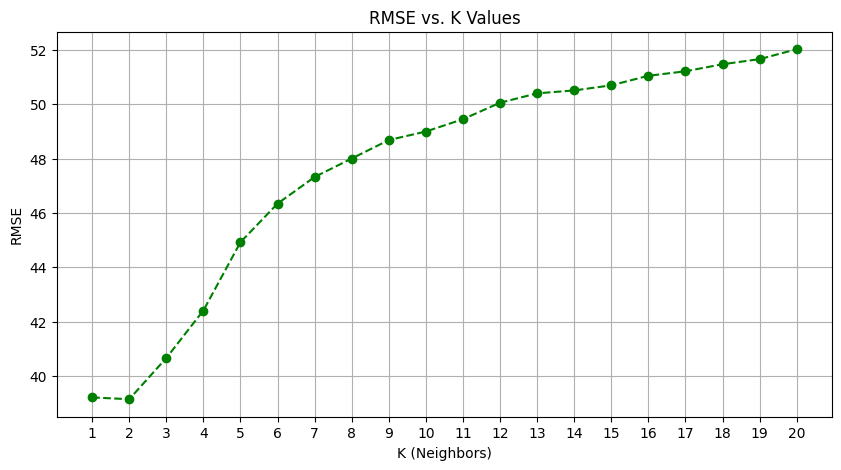

In [42]:
# View the Elbow Curve graph.
plt.figure(figsize=(10, 5))
plt.plot(k_range, rmse_val, marker='o', linestyle='dashed', color='green')
plt.title('RMSE vs. K Values')
plt.xlabel('K (Neighbors)')
plt.ylabel('RMSE')
plt.xticks(k_range)
plt.grid(True)
plt.show()

## 20. Seleção do Melhor Modelo KNN

Após analisar visualmente o gráfico, utilizamos o método `argmin` do **NumPy** para encontrar matematicamente o índice do menor erro na lista `rmse_val`.

Este código automatiza a decisão:
1.  Identifica o menor valor de erro (RMSE).
2.  Recupera o valor de $K$ correspondente.
3.  Armazena-o na variável `best_k`.

Este será o valor utilizado para treinar o nosso modelo KNN final e compará-lo com a Regressão Linear na próxima etapa.

In [44]:
best_k = k_range[np.argmin(rmse_val)]
print(f"The best K found for realistic data is: {best_k}")

The best K found for realistic data is: 2


## 21. Treino do Modelo KNN Otimizado

Com o melhor hiperparâmetro identificado ($K=$ `best_k`), instanciei e treinei a versão final do nosso modelo KNN.

**O processo de treino (`.fit`):**
Ao contrário da Regressão Linear, que aprende uma equação matemática, o KNN "aprende" simplesmente memorizando os pontos de dados de treino num espaço multidimensional.
* Quando pedirmos uma previsão, ele calculará a distância entre o novo ponto e estes pontos memorizados.
* É por isso que a **normalização** (feita anteriormente com o `StandardScaler`) foi tão importante: ela garante que o cálculo da distância seja justo para todas as variáveis.

In [45]:
knn_real = KNeighborsRegressor(n_neighbors=best_k)
knn_real.fit(X_train_scaled, y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 22. Previsão, Métricas e Comparação Final

Nesta etapa, utilizamos o modelo KNN treinado para gerar previsões (`y_pred_knn`) no conjunto de teste. Em seguida, calculamos as métricas de erro (MAE, RMSE, R²) para permitir uma comparação direta e justa com a Regressão Linear.

**Métricas Calculadas:**
* **MAE (Erro Médio Absoluto):** Quanto erramos, em média, em dólares?
* **RMSE (Raiz do Erro Quadrático Médio):** Quanto erramos, penalizando erros grandes?
* **R² (Coeficiente de Determinação):** Qual a percentagem da variação do preço que conseguimos explicar?

**O Confronto Final:**
Ao colocarmos lado a lado o R² da Regressão Linear e do KNN, podemos responder à pergunta central deste projeto:
* *Para prever preços de ações em tendência, é melhor usar uma equação linear ou procurar padrões vizinhos no passado?*

In [47]:
y_pred_knn = knn_real.predict(X_test_scaled)

In [48]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

In [ ]:
print(f"--- Resultados KNN (K={best_k}) ---")
print(f"MAE:  ${mae_knn:.2f}")
print(f"RMSE: ${rmse_knn:.2f}")
print(f"R²:   {r2_knn:.4f}")
print("-" * 40)
print(f"Comparação R² (Regressão Linear): {r2:.4f}") 


--- Resultados KNN (K=2) ---
MAE:  $24.83
RMSE: $39.14
R²:   -0.6456
----------------------------------------
Comparação R² (Regressão Linear): 0.8649


## 23. Batalha de Modelos: Visualização Comparativa

Nesta etapa final, criei um gráfico decisivo para comparar visualmente o desempenho dos dois algoritmos contra os dados reais.

Sobrepomos três linhas no mesmo eixo temporal:
1.  **Preço Real (Azul):** A "verdade" do mercado. O movimento que realmente aconteceu.
2.  **Regressão Linear (Vermelho):** As previsões do modelo linear.
3.  **KNN (Verde):** As previsões do modelo baseado em vizinhos.

**O que analisar neste gráfico?**
* **Capacidade de Extrapolação:** Observe atentamente os momentos em que o preço atinge novos máximos (como em Janeiro de 2024).
    * A **Regressão Linear** tende a acompanhar a subida porque entende a tendência ($y = mx + b$).
    * O **KNN** tende a "bater num teto" (ficar plano), pois não consegue prever valores mais altos do que aqueles que viu no treino.

Este gráfico confirma visualmente por que razão as métricas de erro ($R^2$, RMSE) favoreceram um modelo em detrimento do outro. 

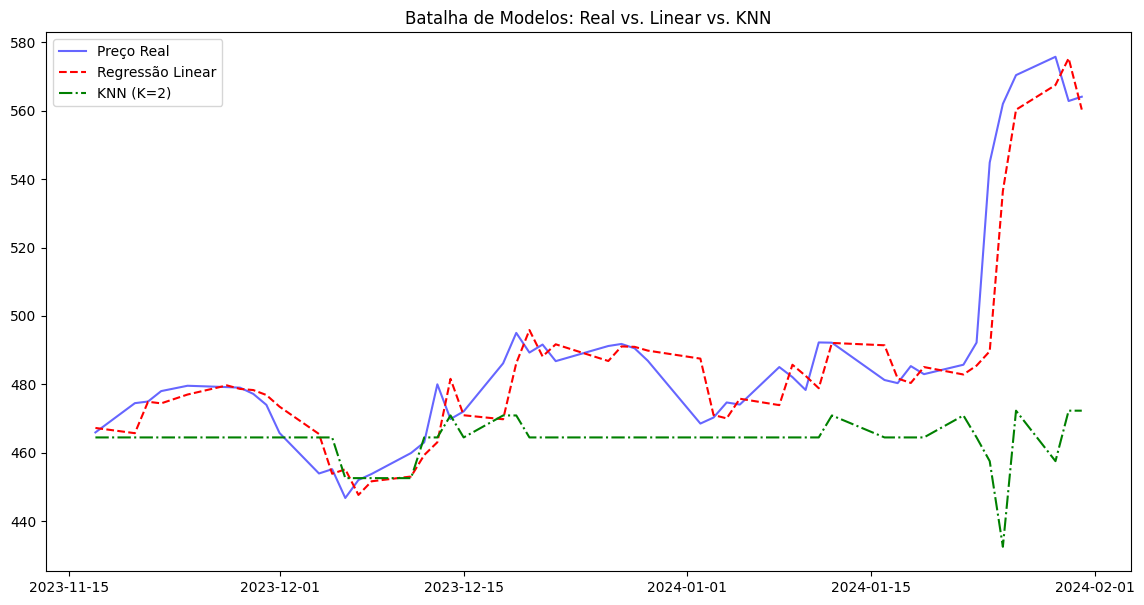

In [59]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Preço Real', color='blue', alpha=0.6)
plt.plot(y_test.index, y_pred, label='Regressão Linear', color='red', linestyle='--')
plt.plot(y_test.index, y_pred_knn, label=f'KNN (K={best_k})', color='green', linestyle='-.')
plt.title('Batalha de Modelos: Real vs. Linear vs. KNN')
plt.legend()
plt.show()

## 24. Geração de Entregáveis: Exportação das Previsões

Nesta etapa final, foram consolidados os resultados obtidos pelo nosso modelo selecionado (Regressão Linear) para cumprir os requisitos de entrega do projeto.

**Procedimento:**
1.  **Seleção do Subconjunto:** Foquei exclusivamente no conjunto de **Teste** (os últimos 20% dos dados, ordenados cronologicamente), conforme solicitado.
2.  **Consolidação:** Criamos um novo *DataFrame* que alinha a Data (`Date`), o Valor Real (`Real_Close`) e a Estimativa do Modelo (`Predicted_Close`).
3.  **Exportação:** Guardamos estes dados no ficheiro `precos_estimados.csv`.

Este ficheiro contém as previsões diárias padronizadas, permitindo uma análise externa da performance do modelo dia a dia.

In [68]:
final_submission = pd.DataFrame(y_pred.round(2), columns=['preco'])

final_submission.to_csv('precos_estimados.csv', index=False)

print(f"Ficheiro 'precos_estimados.csv' gerado com {len(final_submission)} linhas.")
print("Primeiras 5 linhas do ficheiro:")
display(final_submission.head())

Ficheiro 'precos_estimados.csv' gerado com 50 linhas.
Primeiras 5 linhas do ficheiro:


,preco
0,467.22
1,465.69
2,474.88
3,474.41
4,476.99
